# Aula 05 - Aprendizagem de Máquina (Parte IV)

## Aprendizagem não supervisionada

Nesta aula, discutiremos diferentes técnicas de aprendizagem não supervisionada e técnicas de clusterização (agrupamento). Depois de estudar os conceitos básicos como distância e similaridade, taxonomia das técnicas de clusterização e qualidade da clusterização, vamos explorar três técnicas básicas: K-means, clusterização espectral e clusterização hierárquica. Ao final, ilustraremos o uso de técnicas de clusterização em um problema real: definir grupos de países de acordo com seus gastos econômicos com educação.

## Introdução à aprendizagem não supervisionada

Em aprendizagem de máquina, os métodos não supervisionados tentam **encontrar uma "estrutura oculta" em dados não rotulados (classificados)**. Uma vez que os exemplos fornecidos não estão rotulados, não há **nenhum sinal de erro ou recompensa** para avaliar uma solução potencial. Isso distingue a aprendizagem não supervisionada da supervisionada.

A aprendizagem não supervisionada é definida como o conjunto de algoritmos que aprende com um **conjunto de treinamento de exemplos não rotulados ou não anotados**, usando as features de entrada para categorizá-las juntas de acordo com alguns critérios **geométricos** ou **estatísticos** .

A aprendizagem não supervisionada engloba muitas técnicas que buscam **resumir e explicar as principais features** dos dados. Muitos métodos empregados na aprendizagem não supervisionada são baseados em métodos de *mineração de dados* usados para pré-processar dados.

Diferentes *tipos* de poblemas típicos solucionados por meio da aprendizagem não supervisionada:

+ *Clusterização:* exemplos de partição em grupos quando nenhuma categoria / classe predefinida está disponível.
+ *Redução da dimensionalidade:* análise de componente principal, análise de componente independente, fatoração de matriz não negativa.
+ *Detecção de outliers:* encontrar eventos incomuns.
+ *Detecção de novidades:* encontrar mudança nos dados.

A atividade não supervisionada mais comum é a **clusterização**. Nesta aula, vamos nos concentrar nas atividades de clusterização e redução de dimensionalidade.

## Clusterização

**Particionar** exemplos não rotulados em *subconjuntos de clusters*, de modo que:

* Os exemplos dentro de um cluster sejam semelhantes (*alta similaridade intra-classe*).
* Os exemplos em clusters diferentes sejam diferentes (*baixa semelhança entre classes*).

Isso pode ajudar a descobrir novas categorias de maneira não supervisionada (nenhum rótulo de categoria de amostra fornecido).

### Questões importantes que devem ser consideradas na clusterização

+ O que é um *agrupamento natural* entre os exemplos do conjunto de dados? 
    + Definição de "grupo"
    + Definição de "similaridade / distância"

+ *Como agrupar* os exemplos?

+ *Quantos* grupos (clusters)?
    + Fixo a priori?
    + Completamente orientado pelos dados?
    + Evitar clusters “triviais” - muito grande ou muito pequeno...
    + Quais métodos funcionam quando o número de exemplos é grande?
    + Quais métodos funcionam quando o número de classes 'grande?

+ *O que* é um *bom agrupamento*? 
    + Quais métricas podem ser definidas para avaliar a qualidade dos clusters

+ Em qual espaço *agrupar*? 
    + O que fazer em espaços de features com muitas dimensões?
 

<div class="alert alert-info"> **CONCEITO IMPORTANTE:** Clusterização é um tema subjetivo.
</div>

A clusterização irá nos ajudar a analisar e obter uma boa visão dos dados, mas a qualidade do agrupamento **depende do aplicação e do analista**.

## Distância e similaridade

O conceito de similaridade é complexo, mas podemos substitui-lo pela noção de distância.

A métrica de distância mais conhecida é a distância de Minkowski:

$$d(a,b) = \big(\sum\limits_{i=1}^d |a_i-b_i|^p \big)^{1/p}$$

As instâncias mais conhecidas dessa métrica são: 

+ $p = 2$ distância Euclidiana, 
+ $p=1$ distância Manhattan, e 
+ $p=\infty$ max-distance.

## Técnicas de clusterização: como agrupar os exemplos?

Existem duas grandes famílias de técnicas de classificação:

+ **Algoritmos de particionamento:** Começam com uma partição randômica e a refinam iterativamente.
+ **Algoritmos hierárquicos:** aglomerativos (bottom-up) ou top-down.

### Algoritmos de particionamento

São divididos em dois tipos:

+ Algoritmos de partição rígida, como *K-means*, atribuem um valor de cluster exclusivo para cada elemento no espaço de features.
+ Algoritmos de partição suaves, como *Mixture of Gaussians*, podem ser vistos como estimadores de densidade, e atribuem uma confiança ou probabilidade a cada exemplo no espaço de features.

Para entender o conceito de agrupamento, começaremos com o método mais simples e mais famoso: K-means.

### Algoritmo K-means

**Algoritmo:**
1. Definir o valor de  $K$ clusters.
2. Inicializar o valor do centróide (ponto de referência) de cada cluster $K$ cluster centers, randomicamente.
3. Associar a um determinado cluster as N amostras de dados, atribuindo-as aos centróides do cluster mais próximos.
4. Re-estimar o centróide de cada cluster $K$, assumindo que os exemplos estão associados aos clusters corretos.
5. Se nenhum dos exemplos mudou de cluster na última iteração, encerrar o algoritmo. Caso contrário, volta ao passo 3.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt

%matplotlib inline 
plt.style.use('seaborn-whitegrid')
#plt.rc('text', usetex=True)
plt.rc('font', family='times')
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

In [2]:
import numpy as np


#Criar alguns dados
MAXN=40
X = np.concatenate([1.25*np.random.randn(MAXN,2), 5+1.5*np.random.randn(MAXN,2)]) 
X = np.concatenate([X,[8,3]+1.2*np.random.randn(MAXN,2)])
X.shape

(120L, 2L)

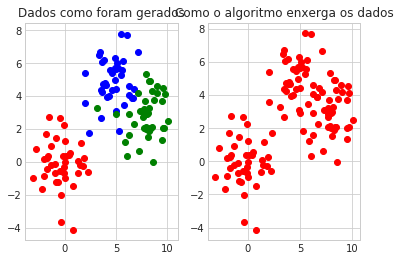

In [4]:
#Apenas para propósitos de visualização, criar rótulos de 3 distribuições
y = np.concatenate([np.ones((MAXN,1)),2*np.ones((MAXN,1))])
y = np.concatenate([y,3*np.ones((MAXN,1))])

plt.subplot(1,2,1)
plt.scatter(X[(y==1).ravel(),0],X[(y==1).ravel(),1],color='r')
plt.scatter(X[(y==2).ravel(),0],X[(y==2).ravel(),1],color='b')
plt.scatter(X[(y==3).ravel(),0],X[(y==3).ravel(),1],color='g')
plt.title('Dados como foram gerados')

plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],color='r')
plt.title('Como o algoritmo enxerga os dados')

plt.savefig("sample.png",dpi=300, bbox_inches='tight')


In [5]:
from sklearn import cluster

K=3 # Assumir que os dados estão divididos em 3 clusters

clf = cluster.KMeans(init='random', n_clusters=K)
clf.fit(X)

KMeans(algorithm='auto', copy_x=True, init='random', max_iter=300,
    n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

**Observação**: cada algoritmo de clusterização possui duas variantes: uma classe, que implementa o método *fit* para aprender a clusterizar com os dados de treinamento, e uma função *predict*, que, dados os dados de teste, retorna um array de inteiros com os rótulos correspondentes aos diferentes clusters. Os rótulos sobre os dados de treinamento podem ser encontrados no atributo *labels_*.

In [6]:
print (clf.labels_)    # ou
#print clf.predict(X) # equivalente

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2
 1 2 2 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


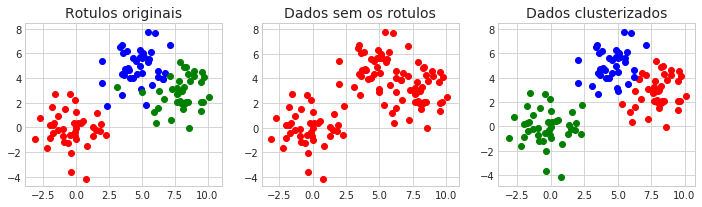

In [7]:
clf = cluster.KMeans(init='random', n_clusters=K, random_state=0) 

clf.fit(X) 
Zx=clf.predict(X)

plt.subplot(1,3,1)
plt.title('Rotulos originais', size=14)
plt.scatter(X[(y==1).ravel(),0],X[(y==1).ravel(),1],color='r')
plt.scatter(X[(y==2).ravel(),0],X[(y==2).ravel(),1],color='b') # b
plt.scatter(X[(y==3).ravel(),0],X[(y==3).ravel(),1],color='g')  # g
fig = plt.gcf()
fig.set_size_inches((12,3))

plt.subplot(1,3,2)
plt.title('Dados sem os rotulos', size=14)
plt.scatter(X[(y==1).ravel(),0],X[(y==1).ravel(),1],color='r')
plt.scatter(X[(y==2).ravel(),0],X[(y==2).ravel(),1],color='r') # b
plt.scatter(X[(y==3).ravel(),0],X[(y==3).ravel(),1],color='r')  # g
fig = plt.gcf()
fig.set_size_inches((12,3))

plt.subplot(1,3,3)
plt.title('Dados clusterizados', size=14)
plt.scatter(X[(Zx==1).ravel(),0],X[(Zx==1).ravel(),1],color='r')
plt.scatter(X[(Zx==2).ravel(),0],X[(Zx==2).ravel(),1],color='b')
plt.scatter(X[(Zx==0).ravel(),0],X[(Zx==0).ravel(),1],color='g')
fig = plt.gcf()
fig.set_size_inches((12,3))


Avaliação da Clusterização:

In [8]:
from sklearn import metrics

clf = cluster.KMeans(n_clusters=K, init='k-means++',  random_state=0, 
                     max_iter=300, n_init=10) 
                                        #initialize the k-means clustering
clf.fit(X)                              #run the k-means clustering

print ('Avaliação final da clusterização:')

print('Inertia: %.2f' %  clf.inertia_)

print('Adjusted_rand_score %.2f' % metrics.adjusted_rand_score(y.ravel(), clf.labels_))

#Homogeneity: valor no intervalo [0, 1] e valores próximos a 1 são melhores
print('Homogeneity %.2f' %  metrics.homogeneity_score(y.ravel(), clf.labels_))

#Completeness: valor no intervalo [0, 1] e valores próximos a 1 são melhores
print('Completeness %.2f' %  metrics.completeness_score(y.ravel(), clf.labels_))
             
#V_measure: média harmônica entre Homogeneity e Completeness; e valores próximos a 1 são melhores
print('V_measure %.2f' %  metrics.v_measure_score(y.ravel(), clf.labels_))

#Silhouette: valor no intervalo [-1, 1]; valores positivos próximos a 1 significam clusters compactos.
print('Silhouette %.2f' %  metrics.silhouette_score(X, clf.labels_, metric='euclidean'))

Avaliação final da clusterização:
Inertia: 384.51
Adjusted_rand_score 0.84
Homogeneity 0.81
Completeness 0.81
V_measure 0.81
Silhouette 0.55


In [9]:
clf1 = cluster.KMeans(n_clusters=K,  init='random', random_state=0, 
                      max_iter=2, n_init=2) 
                                    #initialize the k-means clustering
clf1.fit(X)                         #run the k-means clustering

print ('Avaliação final da clusterização:')

print ('Inertia: %.2f' % clf1.inertia_)

print ('Adjusted_rand_score %.2f' % metrics.adjusted_rand_score(y.ravel(), 
                                                            clf1.labels_))

print ('Homogeneity %.2f' % metrics.homogeneity_score(y.ravel(), 
                                                      clf1.labels_))

print ('Completeness %.2f' % metrics.completeness_score(y.ravel(), 
                                                        clf1.labels_))
             
print ('V_measure %.2f' % metrics.v_measure_score(y.ravel(), 
                                                  clf1.labels_))

print ('Silhouette %.2f' % metrics.silhouette_score(X, clf1.labels_, 
                                                    metric='euclidean'))

Avaliação final da clusterização:
Inertia: 682.93
Adjusted_rand_score 0.66
Homogeneity 0.67
Completeness 0.68
V_measure 0.68
Silhouette 0.46


### Clusterização Espectral

Até este ponto, consideramos o agrupamento como encontrar grupos de dados seguindo uma noção de compactação. Outra forma de ver o que é um cluster é dada pela conectividade (ou similaridade).

**Clusterização espectral** refere-se a uma família de métodos que usam técnicas espectrais. Especificamente, essas técnicas estão relacionadas à autodecomposição de uma matriz de afinidade ou similaridade, e tentam resolver o problema de agrupamento de acordo com a similaridade.
Vamos considerar uma matriz de similaridade ideal de dois conjuntos claros.

Vamos ilustrar o método em alguns exemplos com distribuição não gaussiana. O Scikit-learn tem uma biblioteca para gerar conjuntos de dados com diferentes formas, como luas, bolhas, etc.

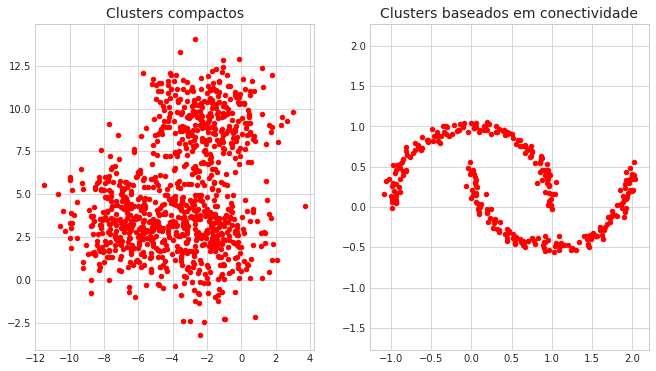

In [14]:
from sklearn.datasets.samples_generator import make_blobs,make_moons

X, labels_true = make_blobs(n_samples=1000, centers=3, cluster_std=[1.7,1.7,1.7])

plt.subplot(1,2,1)
plt.scatter(X[:, 0], X[:, 1], c='r', marker='o',s=20) 
plt.axis('equal')
plt.title('Clusters compactos',size=14)

[Xmoons, ymoons] = make_moons(n_samples=300, noise=.05)
plt.subplot(1,2,2)
plt.scatter(Xmoons[:, 0], Xmoons[:, 1], c='r', marker='o',s=20) 
plt.axis('equal')
plt.title('Clusters baseados em conectividade', size=14)
fig = plt.gcf()
fig.set_size_inches((11,6))

Vamos aplicar a clusterização espectral ao exemplo das duas luas.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import euclidean_distances
 
colors = np.array([x for x in 'bgrcmykbgrcmykbgrcmykbgrcmyk'])
colors = np.hstack([colors] * 20)
 
# Normalizar o conjunto de dados
X = StandardScaler().fit_transform(Xmoons)
 
# Calcular distâncias
distances = euclidean_distances(Xmoons)
    
spectral = cluster.SpectralClustering(n_clusters=2, 
                                      affinity="nearest_neighbors")
 
spectral.fit(Xmoons)
y_pred = spectral.labels_.astype(np.int)
            

A seguir, visualizamos os resultados da clusterização espectral:

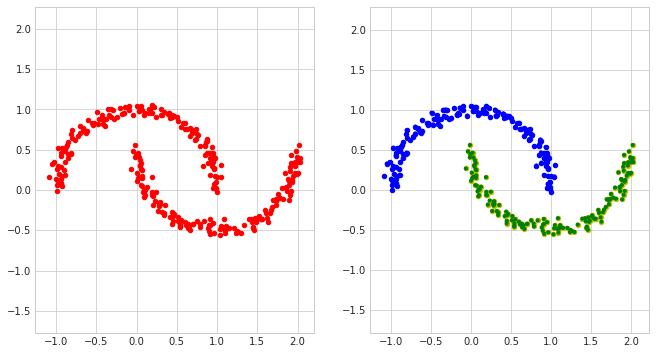

In [18]:

plt.subplot(1,2,1)
plt.scatter(Xmoons[:, 0], Xmoons[:, 1], c='r', marker='o',s=20) 
plt.axis('equal')
 
plt.subplot(1,2,2)
plt.scatter(Xmoons[y_pred==0, 0], Xmoons[y_pred==0, 1], c='b', 
            marker='o',s=20) 
plt.scatter(Xmoons[y_pred==1, 0], Xmoons[y_pred==1, 1], c='y', 
            marker='o',s=20) 
plt.axis('equal')
fig=plt.gcf()
fig.set_size_inches((11,6))
plt.scatter(Xmoons[:, 0], Xmoons[:, 1], color=colors[y_pred].tolist(), 
            s=10)

Vamos comparar com o resultado do K-means:

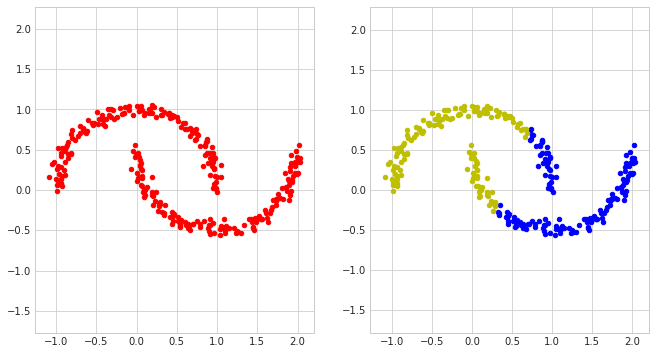

In [19]:
plt.subplot(1,2,1)
plt.scatter(Xmoons[:, 0], Xmoons[:, 1], c='r', marker='o',s=20) 
plt.axis('equal')
 
# Clusterização usando o K-means
clf = cluster.KMeans(n_clusters=2,init='k-means++')
clf.fit(Xmoons)
y_pred=clf.predict(Xmoons)
 
# Visualizar o resultado do K-means
plt.subplot(1,2,2)
plt.scatter(Xmoons[y_pred==0, 0], Xmoons[y_pred==0, 1], c='b', marker='o',s=20) 
plt.scatter(Xmoons[y_pred==1, 0], Xmoons[y_pred==1, 1], c='y', marker='o',s=20) 
plt.axis('equal')
fig=plt.gcf()
fig.set_size_inches((11,6))

Observe que, uma vez que K-means procura por clusters esféricos, ele é incapaz de separar os dados das duas luas, em contraste com o aglomerado espectral.

### Comparando diferentes algoritmos de clusterização

A seguir, comparamos os diferentes algoritmos de clusterização.
Vamos gerar 4 casos de configurações de amostras diferentes:
+ a) grupos circulares separados de dados,
+ b) distribuição uniforme,
+ c) círculos aninhados, e
+ d) configurações não plana de dados.


Para este propósito, scikit-learn tem funções predefinidas, como: datasets.make\_blobs(), datasets.make\_circles(), datasets.make\_moons(), etc.

In [20]:
from sklearn import cluster, datasets

np.random.seed(0)

# Gerar os datasets. 
n_samples = 1500
no_structure = np.random.rand(n_samples, 2), None
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8, centers=4)
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=.5,
                                      noise=.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)

colors = np.array([x for x in 'cmykbgrcmykbgrcmykbgrcmykbgr'])
colors = np.hstack([colors] * 20)

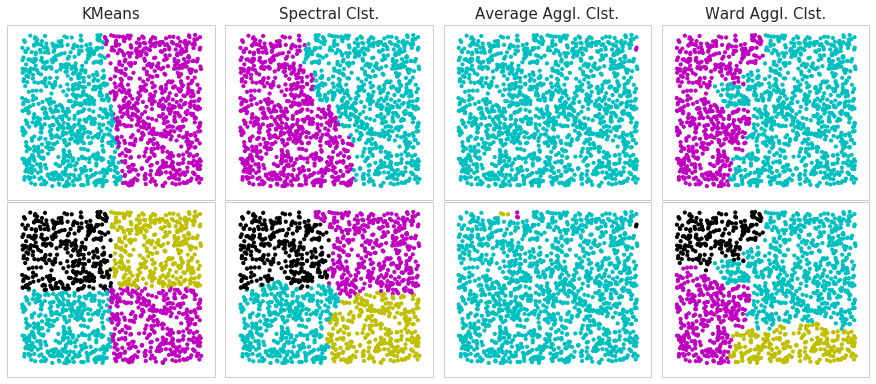

In [21]:
uniform = np.random.rand(n_samples, 2), None

plt.figure(figsize=(12, 10))
plt.subplots_adjust(left=.001, right=.999, bottom=.01, top=.99, wspace=.05, hspace=.01)
plot_num = 1

for i, n_clrs in enumerate([2,4]):
    dataset=uniform
    i_dataset=0
    X, y = dataset
    X = StandardScaler().fit_transform(X)

    connectivity = kneighbors_graph(X, n_neighbors=10)
    connectivity = 0.5 * (connectivity + connectivity.T)

    distances = euclidean_distances(X)

    kmeans = cluster.KMeans(n_clusters=n_clrs)
    spectral_clustering = cluster.SpectralClustering(n_clusters=n_clrs, 
                                          affinity="nearest_neighbors")
    average_agglomerative = cluster.AgglomerativeClustering(linkage="average",connectivity=connectivity,
                            affinity="cityblock", n_clusters=n_clrs)
    ward_agglomerative = cluster.AgglomerativeClustering(n_clusters=n_clrs,
                    linkage='ward', connectivity=connectivity)

    for method, algr in [('KMeans', kmeans),('Spectral Clst.', spectral_clustering),
                            ('Average Aggl. Clst.', average_agglomerative),
                            ('Ward Aggl. Clst.', ward_agglomerative)]:
        algr.fit(X)
        y_pred = algr.labels_.astype(np.int)
        
        plt.subplot(4, 4, plot_num)
        if i == 0:
            plt.title(method, size=15)
        plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
            
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.xticks(())
        plt.yticks(())
        plot_num += 1
plt.savefig("uniform.png",dpi=300, bbox_inches='tight')
plt.show()


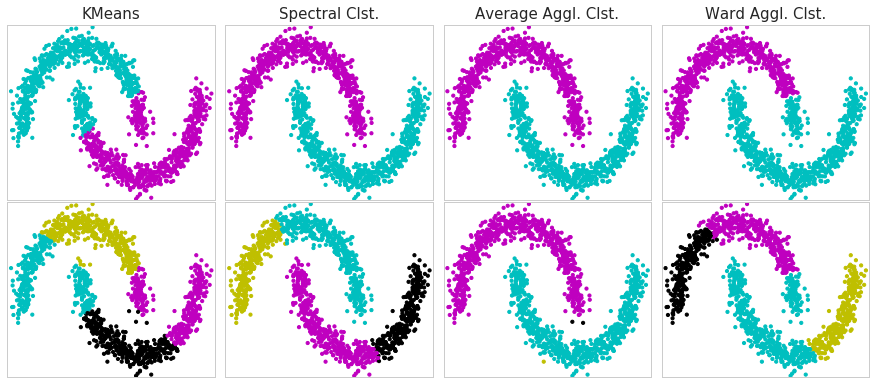

In [22]:
moons = datasets.make_moons(n_samples=n_samples, noise=.08)

plt.figure(figsize=(12, 10))
plt.subplots_adjust(left=.001, right=.999, bottom=.01, top=.99, wspace=.05, hspace=.01)
plot_num = 1

for i, n_clrs in enumerate([2,4]):
    dataset=moons
    X, y = dataset
    X = StandardScaler().fit_transform(X)

    connectivity = kneighbors_graph(X, n_neighbors=10)
    connectivity = 0.5 * (connectivity + connectivity.T)
    distances = euclidean_distances(X)

    kmeans = cluster.KMeans(n_clusters=n_clrs)
    spectral_clustering = cluster.SpectralClustering(n_clusters=n_clrs, affinity="nearest_neighbors")
    average_agglomerative = cluster.AgglomerativeClustering(linkage="average",connectivity=connectivity,
                            affinity="cityblock", n_clusters=n_clrs)
    ward_agglomerative = cluster.AgglomerativeClustering(n_clusters=n_clrs,
                    linkage='ward', connectivity=connectivity)

    for method, algr in [('KMeans', kmeans),('Spectral Clst.', spectral_clustering),
                            ('Average Aggl. Clst.', average_agglomerative),
                            ('Ward Aggl. Clst.', ward_agglomerative)]:
        algr.fit(X)
        y_pred = algr.labels_.astype(np.int)
        
        plt.subplot(4, 4, plot_num)
        if i == 0:
            plt.title(method, size=15)
        plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
            
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.xticks(())
        plt.yticks(())
        plot_num += 1
plt.savefig("plots/moons.png" , bbox_inches='tight')
plt.show()


Código fornecido pelo pacote scikit-learn para comparar diferentes técnicas de clusterização com $k=4$.

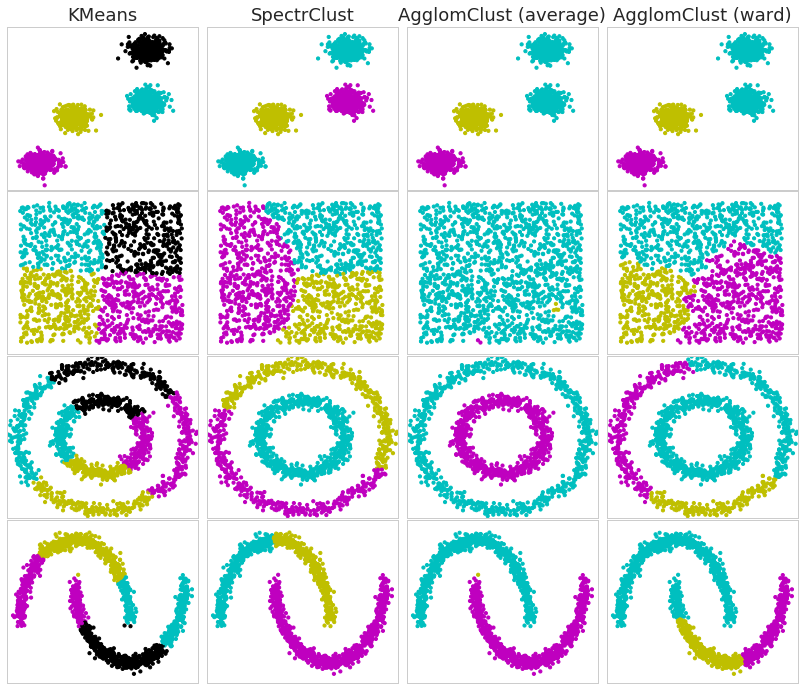

In [23]:
plt.figure(figsize=(11, 9.5))
plt.subplots_adjust(left=.001, right=.999, bottom=.001, top=.96, wspace=.05, hspace=.01)
plot_num = 1

for i_dataset, dataset in enumerate([blobs,
                                     no_structure, noisy_circles, noisy_moons]):
    X, y = dataset
    X = StandardScaler().fit_transform(X)

    connectivity = kneighbors_graph(X, n_neighbors=10)
    connectivity = 0.5 * (connectivity + connectivity.T)

    distances = euclidean_distances(X)

    means = cluster.KMeans(n_clusters=4)
    spectral = cluster.SpectralClustering(n_clusters=3, eigen_solver='arpack',
                                          affinity="nearest_neighbors")
    average_linkage = cluster.AgglomerativeClustering(linkage="average",
                            affinity="cityblock", n_clusters=3,
                            connectivity=connectivity)
    ward = cluster.AgglomerativeClustering(n_clusters=3,
                    linkage='ward', connectivity=connectivity)

    for name, algorithm in [('KMeans', means),('SpectrClust', spectral),
                            ('AgglomClust (average)', average_linkage),
                            ('AgglomClust (ward)', ward)]:
        algorithm.fit(X)
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(np.int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(4, 4, plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)
        plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred].tolist(), s=10)
            
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.xticks(())
        plt.yticks(())
        plot_num += 1


plt.show()
